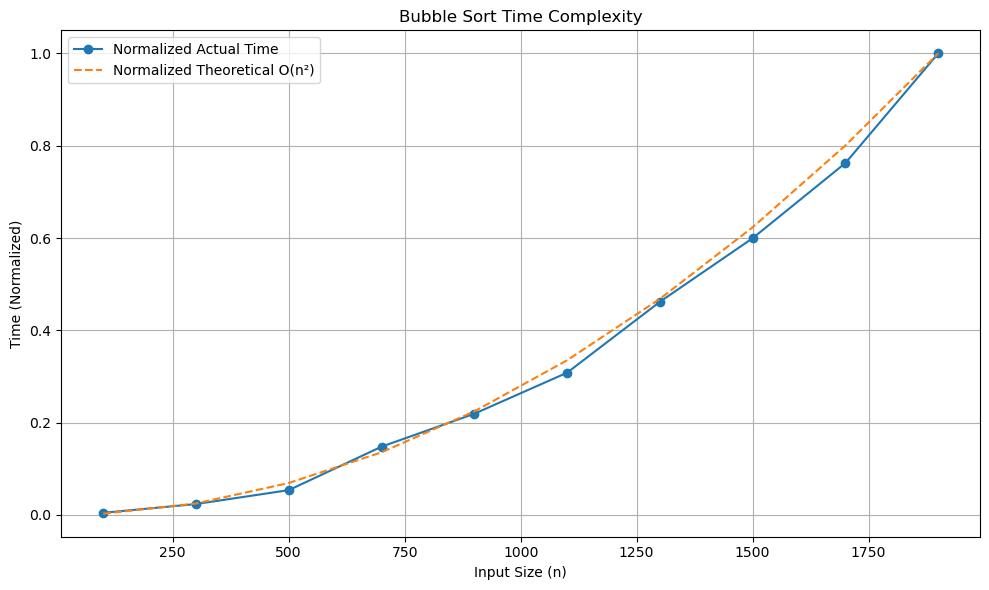

In [ ]:
# Bubble Sort

import time, random
import matplotlib.pyplot as plt

def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(0, n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]

# Time measurement
def measure_times(sizes):
    actual_times = []
    theoretical_times = []

    for n in sizes:
        data = [random.randint(1, 1000) for i in range(n)]
        start_time = time.time()
        bubble_sort(data.copy())
        end_time = time.time()
        actual_times.append(end_time - start_time)
        theoretical_times.append(n ** 2)

    return actual_times, theoretical_times

# Normalization
def norm(times):
    max_time = max(times)
    return [t / max_time for t in times]

sizes = list(range(100, 2001, 200))

actual_times, theoretical_times = measure_times(sizes)
norm_actual = norm(actual_times)
norm_theory = norm(theoretical_times)

plt.figure(figsize=(10, 6))
plt.plot(sizes, norm_actual, label='Normalized Actual Time', marker='o')
plt.plot(sizes, norm_theory, label='Normalized Theoretical O(n²)', linestyle='--')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (Normalized)')
plt.title('Bubble Sort Time Complexity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

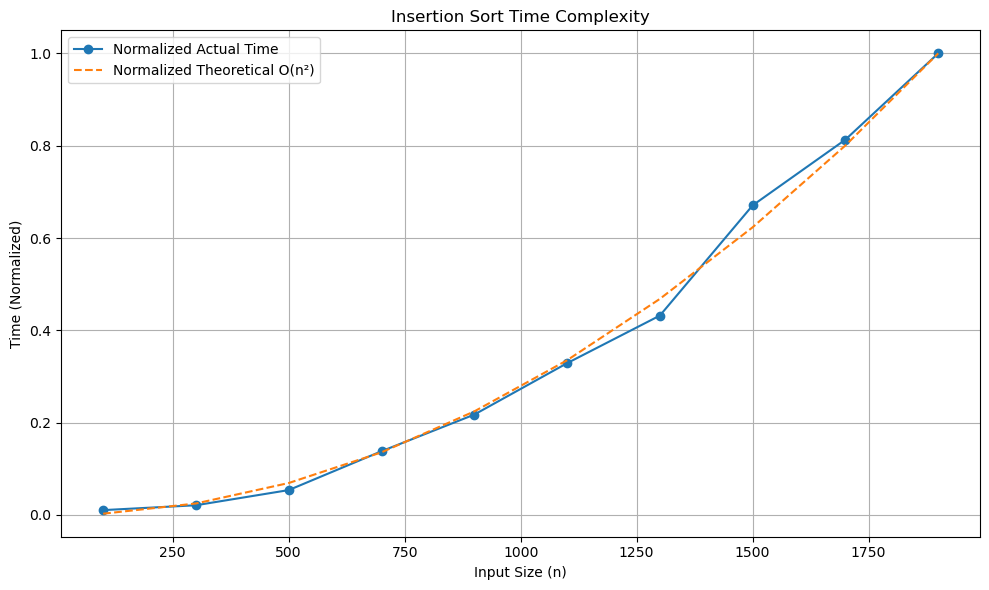

In [15]:
# Insertion Sort

import time, random
import matplotlib.pyplot as plt

def insertion_sort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        while j >= 0 and arr[j] > key:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key

# Time measurement
def measure_times(sizes):
    actual_times = []
    theoretical_times = []

    for n in sizes:
        data = [random.randint(1, 1000) for i in range(n)]
        start_time = time.time()
        insertion_sort(data.copy())
        end_time = time.time()
        actual_times.append(end_time - start_time)
        theoretical_times.append(n ** 2)

    return actual_times, theoretical_times

# Normalization
def norm(times):
    max_time = max(times)
    return [t / max_time for t in times]

sizes = list(range(100, 2001, 200))

actual_times, theoretical_times = measure_times(sizes)
norm_actual = norm(actual_times)
norm_theory = norm(theoretical_times)

plt.figure(figsize=(10, 6))
plt.plot(sizes, norm_actual, label='Normalized Actual Time', marker='o')
plt.plot(sizes, norm_theory, label='Normalized Theoretical O(n²)', linestyle='--')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (Normalized)')
plt.title('Insertion Sort Time Complexity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

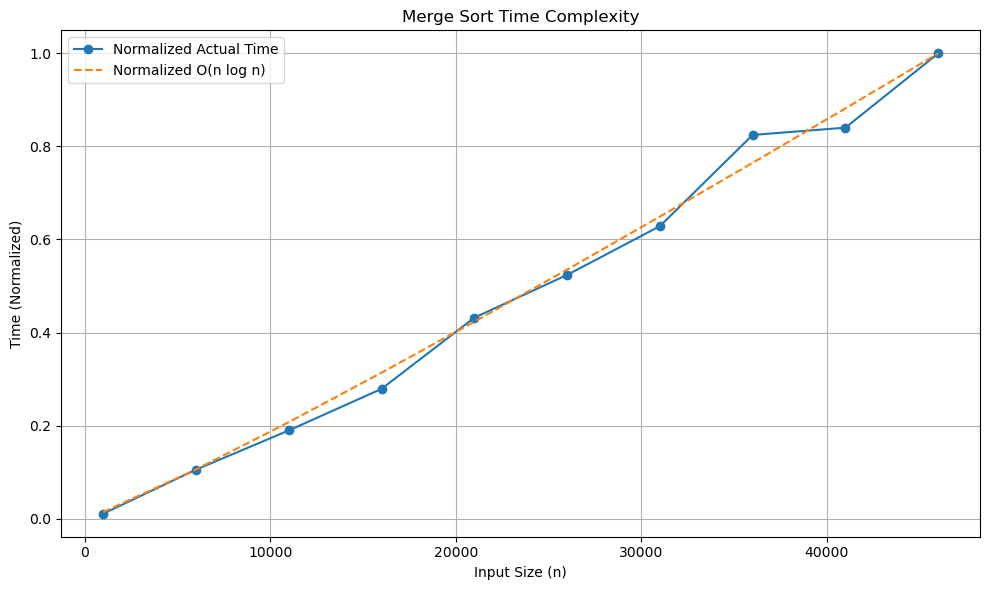

In [22]:
# Merge Sort

import time, random, math
import matplotlib.pyplot as plt

def merge(arr, left, mid, right):
    n1 = mid - left + 1
    n2 = right - mid

    left_part = [0] * (n1 + 1)
    right_part = [0] * (n2 + 1)

    for i in range(n1):
        left_part[i] = arr[left + i]

    for j in range(n2):
        right_part[j] = arr[mid + j + 1]

    left_part[n1] = float('inf')
    right_part[n2] = float('inf')

    i = 0
    j = 0

    for k in range(left, right + 1):
        if left_part[i] <= right_part[j]:
            arr[k] = left_part[i]
            i += 1
        else:
            arr[k] = right_part[j]
            j += 1

def merge_sort(arr, left, right):
    if left < right:
        mid = (left + right) // 2
        merge_sort(arr, left, mid)
        merge_sort(arr, mid + 1, right)
        merge(arr, left, mid, right)

# Time measurement
def measure_times(sizes):
    actual_times = []
    theoretical_times = []

    for n in sizes:
        data = [random.randint(1, 1000) for i in range(n)]
        start = time.time()
        merge_sort(data.copy(), 0, n - 1)
        end = time.time()
        actual_times.append(end - start)
        theoretical_times.append(n * math.log2(n))

    return actual_times, theoretical_times

# Normalization
def norm(times):
    max_time = max(times)
    return [t / max_time for t in times]

sizes = list(range(1000, 50001, 5000))

actual_times, theoretical_times = measure_times(sizes)
norm_actual = norm(actual_times)
norm_theory = norm(theoretical_times)

plt.figure(figsize=(10, 6))
plt.plot(sizes, norm_actual, label='Normalized Actual Time', marker='o')
plt.plot(sizes, norm_theory, label='Normalized O(n log n)', linestyle='--')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (Normalized)')
plt.title('Merge Sort Time Complexity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

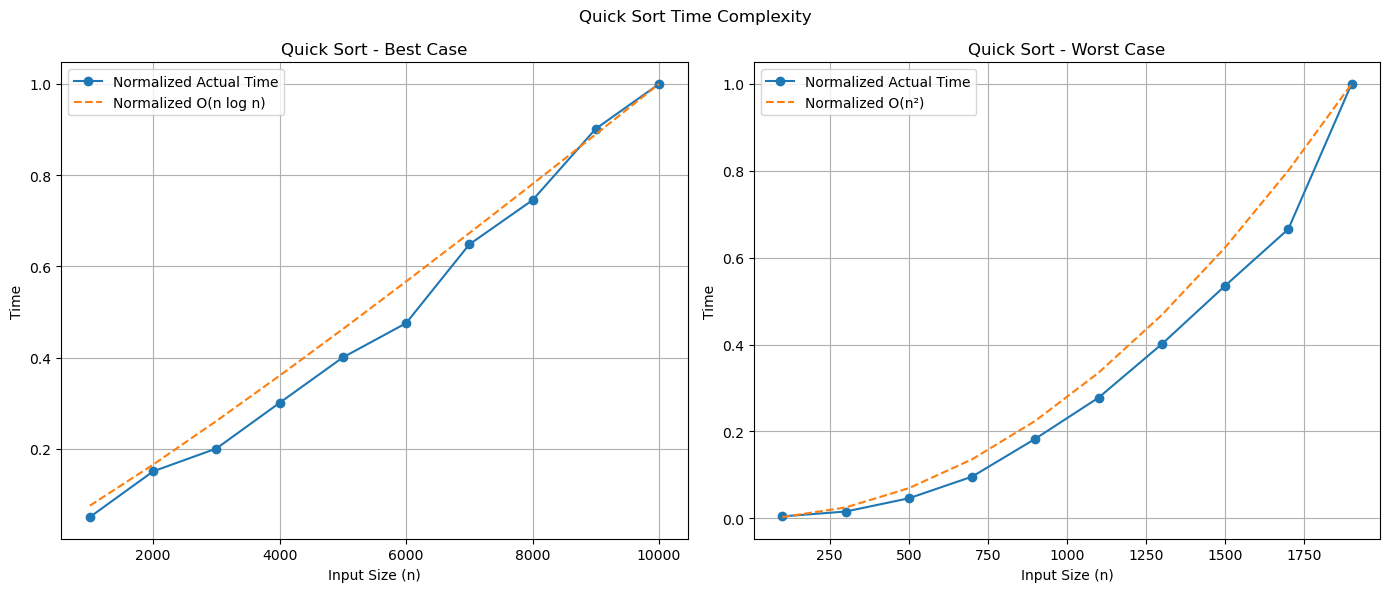

In [84]:
# Quick Sort

import time, random, math
import matplotlib.pyplot as plt

def partition(array, start, end):
    pivot = array[end]
    i = start - 1
    for j in range(start, end):
        if array[j] <= pivot:
            i += 1
            array[i], array[j] = array[j], array[i]
    array[i + 1], array[end] = array[end], array[i + 1]
    return i + 1

def quick_sort(array, start, end):
    if start < end:
        pivot_index = partition(array, start, end)
        quick_sort(array, start, pivot_index - 1)
        quick_sort(array, pivot_index + 1, end)

# Time measurement
def measure_times(sizes1, sizes2):
    best_case_times = []
    worst_case_times = []
    best_theory = []
    worst_theory = []

    # Best case
    for n in sizes1:
        best_data = [random.randint(1, 1000) for i in range(n)]
        start_time = time.time()
        quick_sort(best_data.copy(), 0, n - 1)
        end_time = time.time()
        best_case_times.append(end_time - start_time)
        best_theory.append(n * math.log2(n))

    # Worst case
    for n in sizes2:
        worst_data = list(range(n))
        start_time = time.time()
        quick_sort(worst_data.copy(), 0, n - 1)
        end_time = time.time()
        worst_case_times.append(end_time - start_time)
        worst_theory.append(n ** 2)

    return best_case_times, worst_case_times, best_theory, worst_theory

# Normalization
def normalize(times):
    max_time = max(times)
    return [t / max_time for t in times]

sizes1 = list(range(1000, 10001, 1000))
sizes2 = list(range(100, 2001, 200))

best_case_times, worst_case_times, best_theory, worst_theory = measure_times(sizes1, sizes2)

norm_best = normalize(best_case_times)
norm_worst = normalize(worst_case_times)
norm_best_theory = normalize(best_theory)
norm_worst_theory = normalize(worst_theory)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(sizes1, norm_best, marker='o', label='Normalized Actual Time')
axes[0].plot(sizes1, norm_best_theory, linestyle='--', label='Normalized O(n log n)')
axes[0].set_title('Quick Sort - Best Case')
axes[0].set_xlabel('Input Size (n)')
axes[0].set_ylabel('Time')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(sizes2, norm_worst, label='Normalized Actual Time', marker='o')
axes[1].plot(sizes2, norm_worst_theory, label='Normalized O(n²)', linestyle='--')
axes[1].set_title('Quick Sort - Worst Case')
axes[1].set_xlabel('Input Size (n)')
axes[1].set_ylabel('Time')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Quick Sort Time Complexity')
plt.tight_layout()
plt.show()

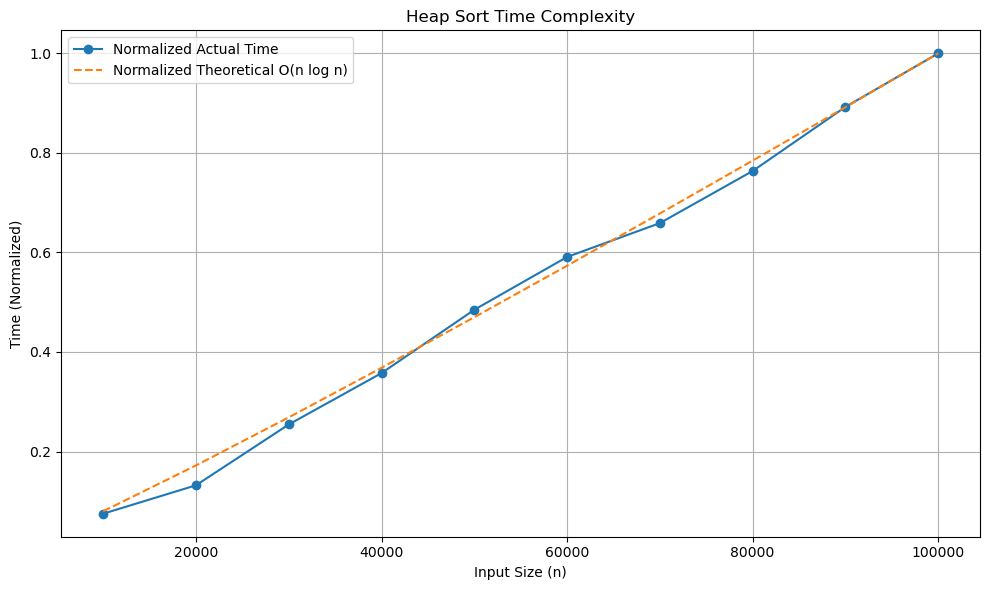

In [ ]:
# Heap Sort

import time
import random
import matplotlib.pyplot as plt
import math

def left(i):
    return 2 * i + 1

def right(i):
    return 2 * i + 2

def max_heapify(arr, size, i):
    largest = i
    l = left(i)
    r = right(i)

    if l < size and arr[l] > arr[largest]:
        largest = l
    if r < size and arr[r] > arr[largest]:
        largest = r
    if largest != i:
        arr[i], arr[largest] = arr[largest], arr[i]
        max_heapify(arr, size, largest)

def build_max_heap(arr):
    size = len(arr)
    for i in range(size // 2 - 1, -1, -1):
        max_heapify(arr, size, i)

def heap_sort(arr):
    size = len(arr)
    build_max_heap(arr)
    for i in range(size - 1, 0, -1):
        arr[0], arr[i] = arr[i], arr[0]
        max_heapify(arr, i, 0)

# Time Measurement
def measure_times(sizes):
    actual_times = []
    theoretical_times = []

    for n in sizes:
        data = [random.randint(1, 1000) for _ in range(n)]
        start_time = time.time()
        heap_sort(data.copy())
        end_time = time.time()
        actual_times.append(end_time - start_time)
        theoretical_times.append(n * math.log2(n))

    return actual_times, theoretical_times

# Normalization
def norm(times):
    max_time = max(times)
    return [t / max_time for t in times]

sizes = list(range(10000, 100001, 10000))

actual_times, theoretical_times = measure_times(sizes)
norm_actual = norm(actual_times)
norm_theory = norm(theoretical_times)

plt.figure(figsize=(10, 6))
plt.plot(sizes, norm_actual, label='Normalized Actual Time', marker='o')
plt.plot(sizes, norm_theory, label='Normalized Theoretical O(n log n)', linestyle='--')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (Normalized)')
plt.title('Heap Sort Time Complexity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

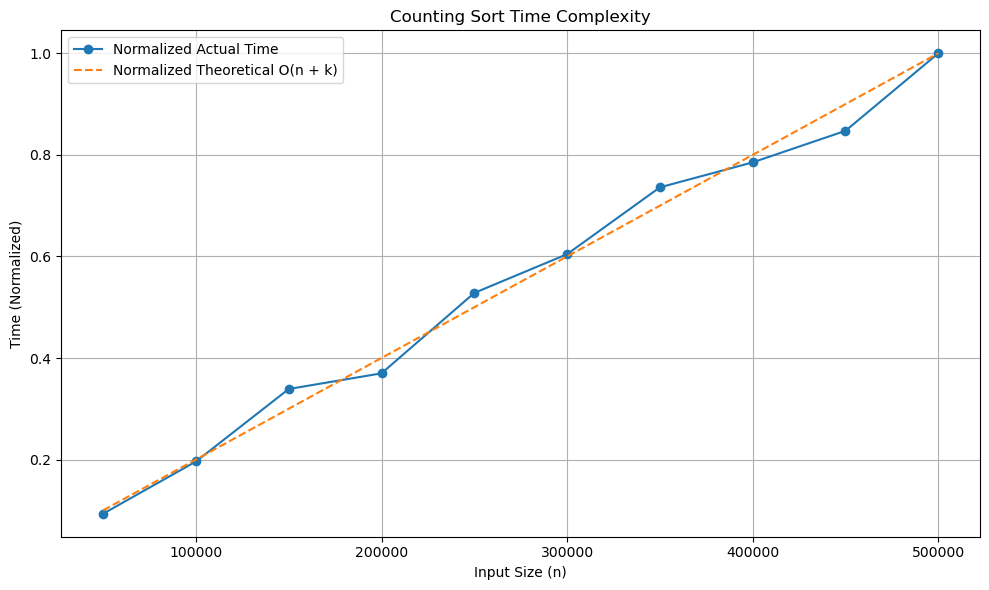

In [ ]:
# Counting Sort

import time
import random
import matplotlib.pyplot as plt

def counting_sort(A, B, k):
    C = [0] * (k + 1)

    for i in range(k + 1):
        C[i] = 0

    for j in range(len(A)):
        C[A[j]] += 1

    for i in range(1, k + 1):
        C[i] += C[i - 1]

    for j in range(len(A) - 1, -1, -1):
        B[C[A[j]] - 1] = A[j]
        C[A[j]] -= 1

    return B

# Time measurement
def measure_times(sizes):
    actual_times = []
    theoretical_times = []

    for n in sizes:
        A = [random.randint(0, 100) for _ in range(n)]
        B = [0] * n
        k = max(A)
        start_time = time.time()
        counting_sort(A, B, k)
        end_time = time.time()
        actual_times.append(end_time - start_time)
        theoretical_times.append(n + k)

    return actual_times, theoretical_times

# Normalization
def norm(times):
    max_time = max(times)
    return [t / max_time for t in times]

sizes = list(range(50000, 500001, 50000))

actual_times, theoretical_times = measure_times(sizes)
norm_actual = norm(actual_times)
norm_theory = norm(theoretical_times)

plt.figure(figsize=(10, 6))
plt.plot(sizes, norm_actual, label='Normalized Actual Time', marker='o')
plt.plot(sizes, norm_theory, label='Normalized Theoretical O(n + k)', linestyle='--')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (Normalized)')
plt.title('Counting Sort Time Complexity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

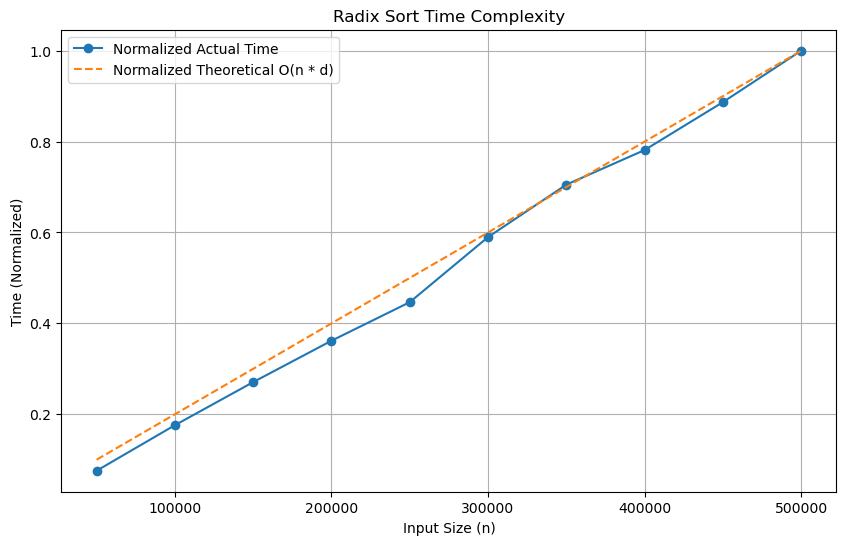

In [ ]:
# Radix Sort

import time, random
import matplotlib.pyplot as plt

def counting_sort(A, k, exp):
    B = [0] * len(A)
    C = [0] * (k + 1)

    for j in range(len(A)):
        index = (A[j] // exp) % 10
        C[index] += 1

    for i in range(1, k + 1):
        C[i] += C[i - 1]

    for j in range(len(A) - 1, -1, -1):
        index = (A[j] // exp) % 10
        B[C[index] - 1] = A[j]
        C[index] -= 1

    return B

def radix_sort(A, d):
    k = 9
    exp = 1

    for i in range(d):
        A = counting_sort(A, k, exp)
        exp *= 10

    return A

# Time measurement
def measure_times(sizes):
    actual_times = []
    theoretical_times = []

    for n in sizes:
        data = [random.randint(0, 99999) for i in range(n)]
        max_digits = len(str(max(data)))
        
        start_time = time.time()
        radix_sort(data.copy(), max_digits)
        end_time = time.time()
        
        actual_times.append(end_time - start_time)
        theoretical_times.append(n * (max_digits))

    return actual_times, theoretical_times

# Normalization
def norm(times):
    max_time = max(times)
    return [t / max_time for t in times]

sizes = list(range(50000, 500001, 50000))

actual_times, theoretical_times = measure_times(sizes)
norm_actual = norm(actual_times)
norm_theory = norm(theoretical_times)

plt.figure(figsize=(10, 6))
plt.plot(sizes, norm_actual, label='Normalized Actual Time', marker='o')
plt.plot(sizes, norm_theory, label='Normalized Theoretical O(n * d)', linestyle='--')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (Normalized)')
plt.title('Radix Sort Time Complexity')
plt.legend()
plt.grid(True)
plt.show()

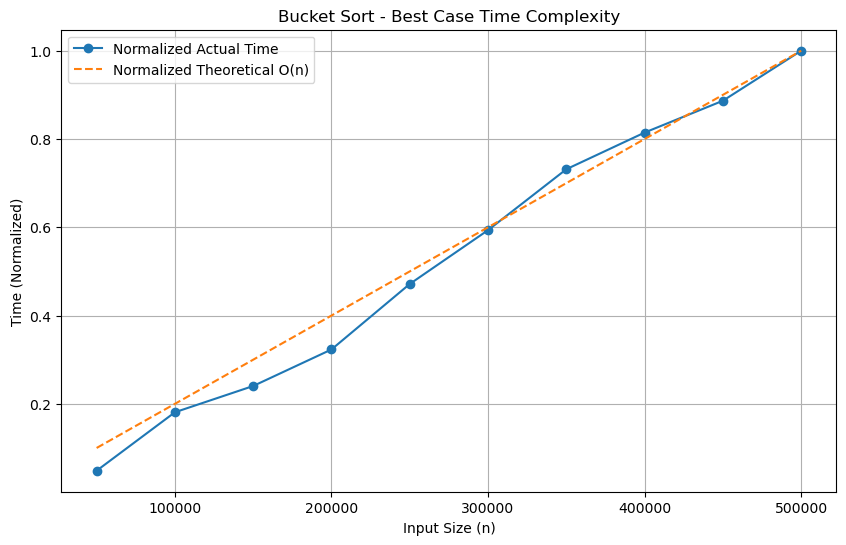

In [ ]:
# Bucket Sort

import time
import random
import matplotlib.pyplot as plt

def insertion_sort(arr):
    for j in range(1, len(arr)):
        key = arr[j]
        i = j - 1
        while i >= 0 and arr[i] > key:
            arr[i + 1] = arr[i]
            i -= 1
        arr[i + 1] = key

def bucket_sort(A):
    n = len(A)
    B = [[] for _ in range(n)]

    for i in range(n):
        index = int(n * A[i])
        if index == n:
            index = n - 1
        B[index].append(A[i])

    for i in range(n):
        insertion_sort(B[i])

    result = []
    for i in range(n):
        result += B[i]

    return result

# Time measurement
def measure_times(sizes):
    best_times, best_theory = [], []

    for n in sizes:
        A_best = [round(random.random(), 2) for _ in range(n)]
        start = time.time()
        bucket_sort(A_best)
        end = time.time()
        best_times.append(end - start)
        best_theory.append(n)

    return best_times, best_theory

# Normalize times
def norm(times):
    max_time = max(times)
    return [t / max_time for t in times]

sizes = list(range(50000, 500001, 50000))
best_times, best_theory = measure_times(sizes)

norm_actual = norm(best_times)
norm_theory = norm(best_theory)

plt.figure(figsize=(10, 6))
plt.plot(sizes, norm_actual, label='Normalized Actual Time', marker='o')
plt.plot(sizes, norm_theory, label='Normalized Theoretical O(n)', linestyle='--')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (Normalized)')
plt.title('Bucket Sort - Best Case Time Complexity')
plt.legend()
plt.grid(True)
plt.show()

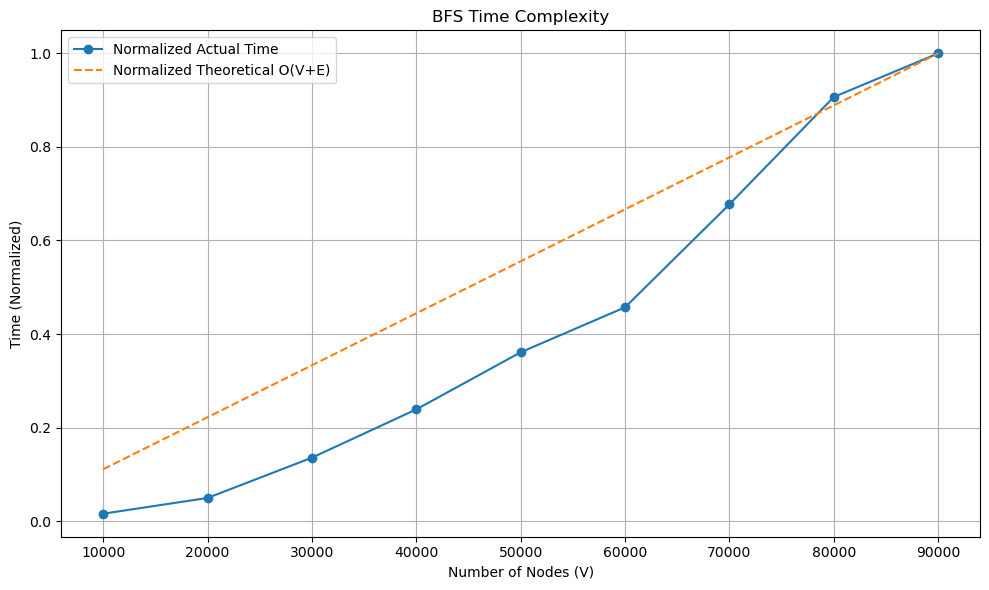

In [ ]:
# BSF (Breadth-First Search)

import time
import random
import matplotlib.pyplot as plt

def bfs(graph, start):
    visited = {}
    for node in graph:
        visited[node] = False

    queue = []
    visited[start] = True
    queue.append(start)

    while queue:
        u = queue.pop(0)
        for w in graph[u]:
            if not visited[w]:
                queue.append(w)
                visited[w] = True

# Graph generator
def generate_graph(num_nodes, edge_factor=2):
    graph = {str(i): [] for i in range(num_nodes)}

    for i in range(1, num_nodes):
        a = str(i)
        b = str(random.randint(0, i - 1))
        graph[a].append(b)
        graph[b].append(a)

    # Add more edges
    target_edges = num_nodes * edge_factor
    current_edges = num_nodes - 1
    while current_edges < target_edges:
        u, v = str(random.randint(0, num_nodes - 1)), str(random.randint(0, num_nodes - 1))
        if u != v and v not in graph[u]:
            graph[u].append(v)
            graph[v].append(u)
            current_edges += 1

    return graph

# Time Measurement
def measure_bfs(sizes, edge_factor=0.01):
    actual = []
    theory = []

    for n in sizes:
        graph = generate_graph(n, edge_factor=0.01)
        num_edges = sum(len(adj) for adj in graph.values()) // 2
        start = random.choice(list(graph.keys()))

        start_time = time.perf_counter()
        bfs(graph, start)
        end_time = time.perf_counter()

        actual.append(end_time - start_time)
        theory.append(n + num_edges)

    return actual, theory

# Normalize times
def normalize(times):
    max_val = max(times)
    return [t / max_val for t in times]

sizes = list(range(10000, 100000, 10000))
edge_factor = 0.01

actual_times, theoretical_times = measure_bfs(sizes, edge_factor)
norm_actual = normalize(actual_times)
norm_theory = normalize(theoretical_times)

plt.figure(figsize=(10, 6))
plt.plot(sizes, norm_actual, label='Normalized Actual Time', marker='o')
plt.plot(sizes, norm_theory, label='Normalized Theoretical O(V+E)', linestyle='--')
plt.xlabel('Number of Nodes (V)')
plt.ylabel('Time (Normalized)')
plt.title('BFS Time Complexity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

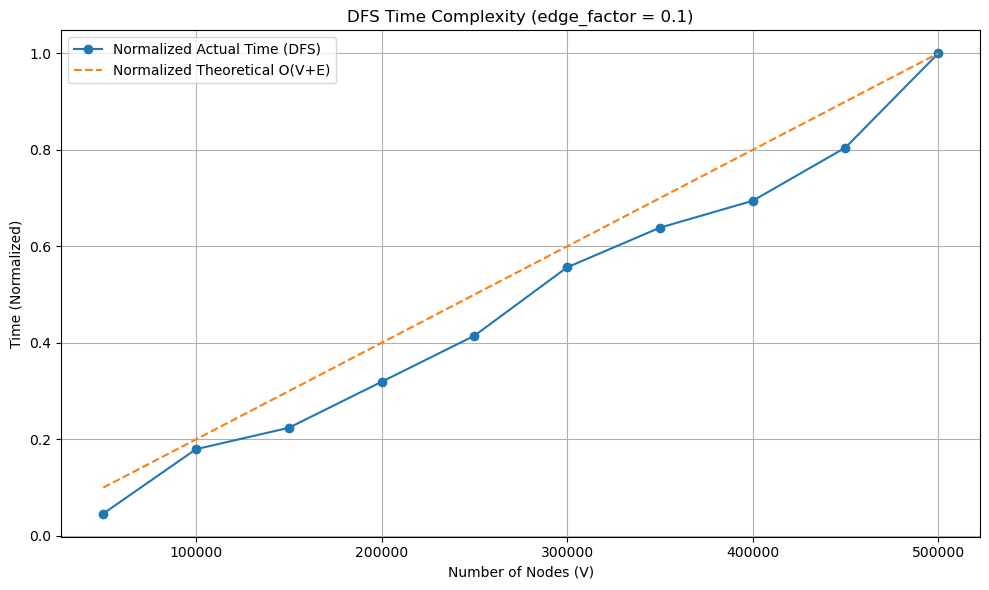

In [ ]:
# DFS (Depth-First Search)

import time
import random
import matplotlib.pyplot as plt

# DFS implementation
def dfs(graph, v, visited):
    visited[v] = True
    # Uncomment to collect nodes in a list instead of printing
    # visited_nodes.append(v)
    
    for i in graph[v]:
        if not visited[i]:
            dfs(graph, i, visited)

# Provided graph generator with controlled edge density
def generate_graph(num_nodes, edge_factor=2):
    graph = {str(i): [] for i in range(num_nodes)}

    # Ensure connectivity
    for i in range(1, num_nodes):
        a = str(i)
        b = str(random.randint(0, i - 1))
        graph[a].append(b)
        graph[b].append(a)

    # Add additional random edges
    target_edges = num_nodes * edge_factor
    current_edges = num_nodes - 1
    while current_edges < target_edges:
        u, v = str(random.randint(0, num_nodes - 1)), str(random.randint(0, num_nodes - 1))
        if u != v and v not in graph[u]:
            graph[u].append(v)
            graph[v].append(u)
            current_edges += 1

    return graph

# Time Measurement
def measure_dfs(sizes, edge_factor=0.1):
    actual = []
    theory = []

    for n in sizes:
        graph = generate_graph(n, edge_factor)
        num_edges = sum(len(adj) for adj in graph.values()) // 2
        start = random.choice(list(graph.keys()))

        start_time = time.perf_counter()
        visited = {key: False for key in graph}
        dfs(graph, start, visited)
        end_time = time.perf_counter()

        actual.append(end_time - start_time)
        theory.append(n + num_edges)

    return actual, theory

# Normalize times
def normalize(times):
    max_val = max(times)
    return [t / max_val for t in times]

# Test with sizes and edge_factor
sizes = list(range(50000, 500001, 50000))  # You can adjust the sizes here
edge_factor = 0.1  # Adjust edge density for sparse graphs

# Measure the DFS performance
actual_times, theoretical_times = measure_dfs(sizes, edge_factor)
norm_actual = normalize(actual_times)
norm_theory = normalize(theoretical_times)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(sizes, norm_actual, label='Normalized Actual Time (DFS)', marker='o')
plt.plot(sizes, norm_theory, label='Normalized Theoretical O(V+E)', linestyle='--')
plt.xlabel('Number of Nodes (V)')
plt.ylabel('Time (Normalized)')
plt.title(f'DFS Time Complexity (edge_factor = {edge_factor})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

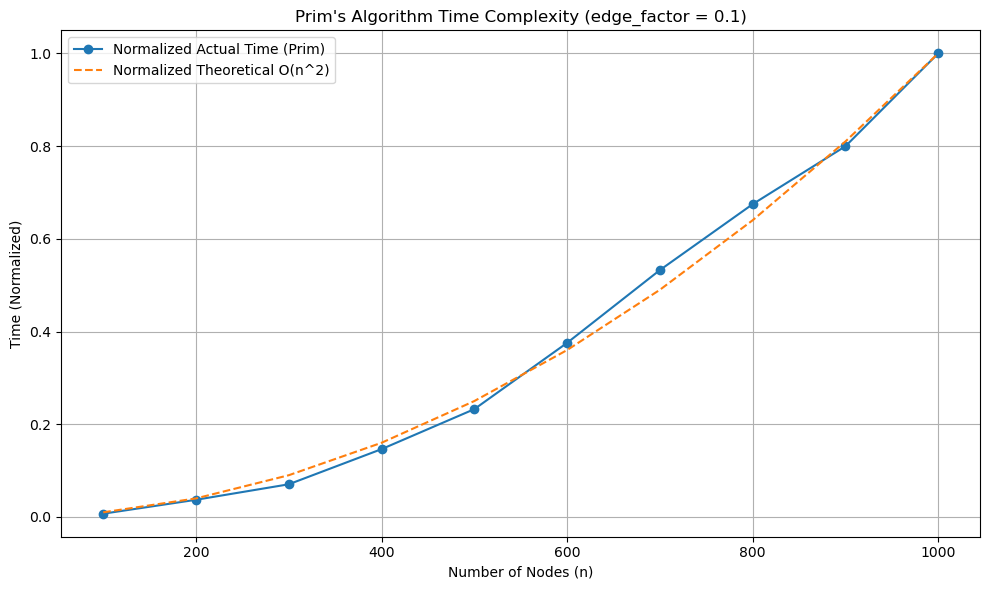

In [ ]:
# Prim's Algorithm

import time
import matplotlib.pyplot as plt
import random

def prim(cost, n):
    near = [0] * n
    t = []
    min_cost = 0

    # Step 1: Find edge with minimum cost
    min_val = float('inf')
    k = l = 0
    for i in range(n):
        for j in range(n):
            if cost[i][j] < min_val and i != j:
                min_val = cost[i][j]
                k, l = i, j

    t.append((k, l))
    min_cost += cost[k][l]

    # Initialize near array
    for i in range(n):
        if cost[i][l] < cost[i][k]:
            near[i] = l
        else:
            near[i] = k

    near[k] = near[l] = -1  # -1 means included in MST

    # Step 2: Construct remaining n-2 edges
    for i in range(n - 2):
        min_val = float('inf')
        j = -1
        for i in range(n):
            if near[i] != -1 and cost[i][near[i]] < min_val:
                j = i
                min_val = cost[i][near[i]]

        t.append((j, near[j]))
        min_cost += cost[j][near[j]]
        near[j] = -1

        for k in range(n):
            if near[k] != -1 and cost[k][near[k]] > cost[k][j]:
                near[k] = j

    return t, min_cost

# Generate a random cost matrix
def generate_cost_matrix(n, edge_factor=0.1):
    INF = float('inf')
    cost = [[INF] * n for _ in range(n)]

    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < edge_factor:
                cost[i][j] = random.randint(1, 10)
                cost[j][i] = cost[i][j]

    for i in range(n):
        cost[i][i] = INF  # No self-loop

    return cost

# Time measurement
def measure_prim(sizes, edge_factor=0.1):
    actual = []
    theory = []

    for n in sizes:
        cost_matrix = generate_cost_matrix(n, edge_factor)
        start_time = time.time()
        edges, total_cost = prim(cost_matrix, n)
        end_time = time.time()

        actual.append(end_time - start_time)
        theory.append(n ** 2)  # Prim's time complexity is O(n^2)

    return actual, theory

# Normalize times
def normalize(times):
    max_val = max(times)
    return [t / max_val for t in times]

# Test with sizes and edge_factor
sizes = list(range(100, 1001, 100))  # Increase size from 10 to 100 nodes
edge_factor = 0.1  # Control edge density

# Measure the Prim's algorithm performance
actual_times, theoretical_times = measure_prim(sizes, edge_factor)
norm_actual = normalize(actual_times)
norm_theory = normalize(theoretical_times)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(sizes, norm_actual, label='Normalized Actual Time (Prim)', marker='o')
plt.plot(sizes, norm_theory, label='Normalized Theoretical O(n^2)', linestyle='--')
plt.xlabel('Number of Nodes (n)')
plt.ylabel('Time (Normalized)')
plt.title(f'Prim\'s Algorithm Time Complexity (edge_factor = {edge_factor})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

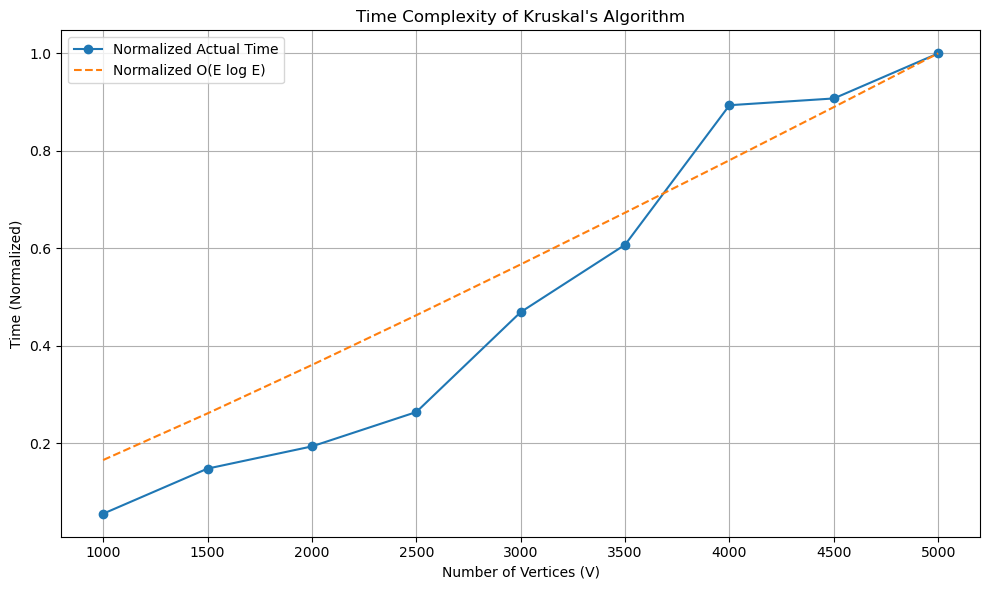

In [ ]:
# Kruskal's Algorithm

import time
import random
import matplotlib.pyplot as plt
import math

def find(u, parent):
    while parent[u] != u:
        u = parent[u]
    return u

def union(u, v, parent):
    parent_u = find(u, parent)
    parent_v = find(v, parent)
    parent[parent_u] = parent_v

def kruskal(n, edge_list):
    parent = [i for i in range(n)]
    edge_list.sort(key=lambda x: x[2])
    
    t = []
    mincost = 0
    i = 0

    for u, v, cost in edge_list:
        if i == n - 1:
            break
        j = find(u, parent)
        k = find(v, parent)
        if j != k:
            t.append((u, v))
            mincost += cost
            union(j, k, parent)
            i += 1

    if i != n - 1:
        return None, []
    else:
        return mincost, t

def generate_connected_graph(n, extra_edges=0):
    edges = []
    connected = list(range(n))
    random.shuffle(connected)

    for i in range(1, n):
        u = connected[i]
        v = connected[random.randint(0, i - 1)]
        weight = random.randint(1, 100)
        edges.append((u, v, weight))

    added = 0
    while added < extra_edges:
        u = random.randint(0, n - 1)
        v = random.randint(0, n - 1)
        if u != v and (u, v, _) not in edges and (v, u, _) not in edges:
            weight = random.randint(1, 100)
            edges.append((u, v, weight))
            added += 1

    return edges

def measure_kruskal(sizes, edge_factor=2):
    actual_times = []
    theoretical = []

    for n in sizes:
        E = n * edge_factor
        edges = generate_connected_graph(n, extra_edges=E - (n - 1))

        start_time = time.time()
        kruskal(n, edges)
        end_time = time.time()

        actual_times.append(end_time - start_time)
        theoretical.append(E * math.log2(E))

    return actual_times, theoretical

def normalize(data):
    max_val = max(data)
    return [d / max_val for d in data]

sizes = list(range(1000, 5001, 500))
actual, theory = measure_kruskal(sizes)
norm_actual = normalize(actual)
norm_theory = normalize(theory)

plt.figure(figsize=(10, 6))
plt.plot(sizes, norm_actual, label="Normalized Actual Time", marker='o')
plt.plot(sizes, norm_theory, label="Normalized O(E log E)", linestyle='--')
plt.xlabel("Number of Vertices (V)")
plt.ylabel("Time (Normalized)")
plt.title("Time Complexity of Kruskal's Algorithm")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

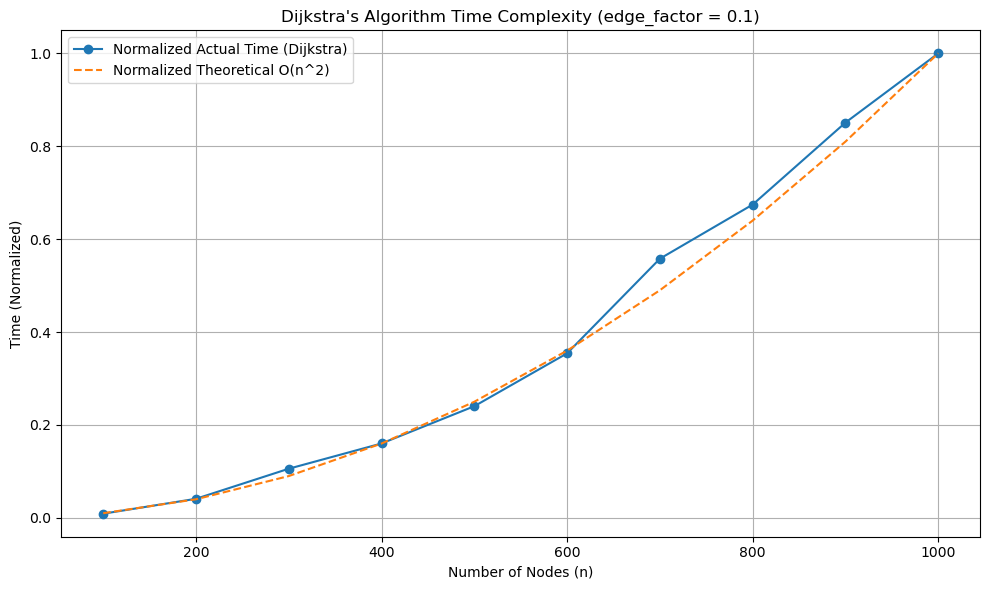

In [ ]:
# Dijkstra's Algorithm

import time
import random
import matplotlib.pyplot as plt

# Dijkstra's algorithm
def dijkstra(v, cost, n):
    INF = float('inf')
    S = [0] * n
    DIST = [INF] * n

    for i in range(n):
        S[i] = 0
        DIST[i] = cost[v][i]

    DIST[v] = 0
    S[v] = 1

    for _ in range(n):
        # Find u such that DIST[u] is minimum and S[u] == 0
        min_dist = INF
        u = -1
        for j in range(n):
            if S[j] == 0 and DIST[j] < min_dist:
                min_dist = DIST[j]
                u = j

        if u == -1:
            break  # No more reachable vertices

        S[u] = 1

        # Update distances for adjacent vertices
        for w in range(n):
            if S[w] == 0 and cost[u][w] != INF:
                DIST[w] = min(DIST[w], DIST[u] + cost[u][w])

    return DIST

# Generate a random cost matrix
def generate_cost_matrix(n, edge_factor=0.1):
    INF = float('inf')
    cost = [[INF] * n for _ in range(n)]

    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < edge_factor:
                cost[i][j] = random.randint(1, 10)
                cost[j][i] = cost[i][j]

    for i in range(n):
        cost[i][i] = INF  # No self-loop

    return cost

# Time measurement
def measure_dijkstra(sizes, edge_factor=0.1):
    actual = []
    theory = []

    for n in sizes:
        cost_matrix = generate_cost_matrix(n, edge_factor)
        start_time = time.time()
        distances = dijkstra(0, cost_matrix, n)
        end_time = time.time()

        actual.append(end_time - start_time)
        theory.append(n ** 2)  # Dijkstra's time complexity is O(n^2) with adjacency matrix

    return actual, theory

# Normalize times
def normalize(times):
    max_val = max(times)
    return [t / max_val for t in times]

# Test with sizes and edge_factor
sizes = list(range(100, 1001, 100))  # Increase size from 10 to 100 nodes
edge_factor = 0.1  # Control edge density

# Measure the Dijkstra algorithm performance
actual_times, theoretical_times = measure_dijkstra(sizes, edge_factor)
norm_actual = normalize(actual_times)
norm_theory = normalize(theoretical_times)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(sizes, norm_actual, label='Normalized Actual Time (Dijkstra)', marker='o')
plt.plot(sizes, norm_theory, label='Normalized Theoretical O(n^2)', linestyle='--')
plt.xlabel('Number of Nodes (n)')
plt.ylabel('Time (Normalized)')
plt.title(f'Dijkstra\'s Algorithm Time Complexity (edge_factor = {edge_factor})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

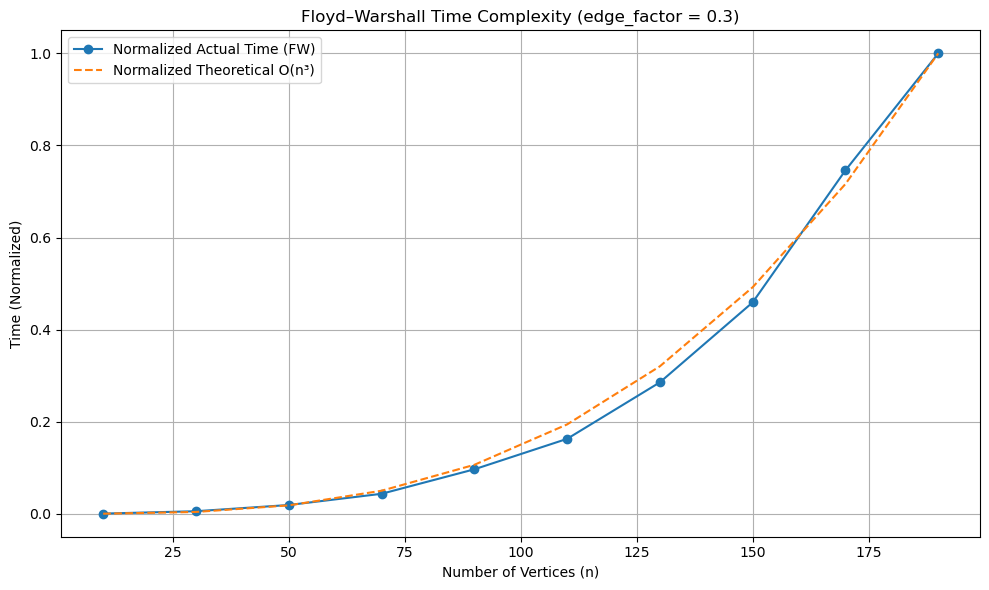

In [ ]:
# Floyd-Warshall Algorithm

import time
import random
import matplotlib.pyplot as plt

INF = float('inf')

# Your Floyd–Warshall implementation
def floyd_warshall(cost, n):
    # Copy cost matrix
    A = [[cost[i][j] for j in range(n)] for i in range(n)]
    for k in range(n):
        for i in range(n):
            for j in range(n):
                A[i][j] = min(A[i][j], A[i][k] + A[k][j])
    return A

# Generate a random cost matrix for a directed graph
def generate_cost_matrix(n, edge_factor=0.3):
    cost = [[INF]*n for _ in range(n)]
    for i in range(n):
        cost[i][i] = 0
        for j in range(n):
            if i != j and random.random() < edge_factor:
                # assign a random weight between 1 and 20
                w = random.randint(1, 20)
                cost[i][j] = w
    return cost

# Measure runtimes of Floyd–Warshall vs. O(n^3)
def measure_fw(sizes, edge_factor=0.3):
    actual = []
    theory = []
    for n in sizes:
        mat = generate_cost_matrix(n, edge_factor)
        start = time.time()
        floyd_warshall(mat, n)
        end = time.time()
        actual.append(end - start)
        theory.append(n**3)
    return actual, theory

# Normalize a list to [0,1]
def normalize(lst):
    m = max(lst)
    return [x/m for x in lst]

# Experiment parameters
sizes = list(range(10, 201, 20))    # graph sizes from 10 to 200
edge_factor = 0.3                   # ~30% density

# Run measurements
actual_times, theory_times = measure_fw(sizes, edge_factor)
norm_actual = normalize(actual_times)
norm_theory = normalize(theory_times)

# Plot
plt.figure(figsize=(10,6))
plt.plot(sizes, norm_actual, marker='o', label='Normalized Actual Time (FW)')
plt.plot(sizes, norm_theory, linestyle='--', label='Normalized Theoretical O(n³)')
plt.xlabel('Number of Vertices (n)')
plt.ylabel('Time (Normalized)')
plt.title(f"Floyd–Warshall Time Complexity (edge_factor = {edge_factor})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

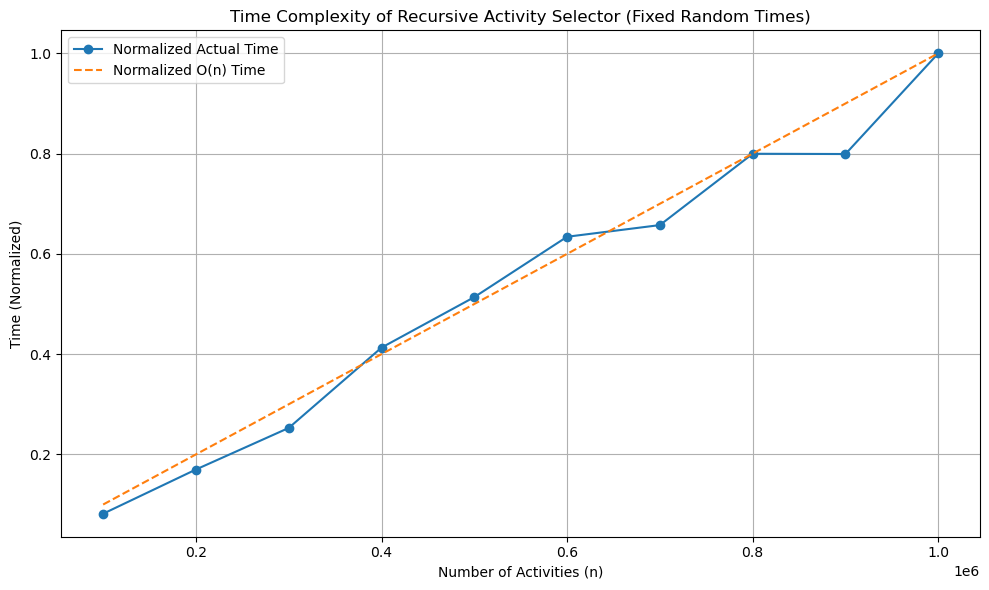

In [ ]:
# Recursive Activity Selector

import time
import random
import matplotlib.pyplot as plt

def recursive_activity_selector(s, f, k, n):
    m = k + 1
    while m <= n and s[m] < f[k]:
        m += 1
    if m <= n:
        return [m] + recursive_activity_selector(s, f, m, n)
    else:
        return []

def measure_recursive_activity_selector(sizes):
    actual_times = []
    theoretical = []

    for n in sizes:
        s_vals = [random.randint(0, 1000) for _ in range(n)]
        f_vals = [s_vals[i] + random.randint(1, 100) for i in range(n)]

        indices = list(range(n))
        indices.sort(key=lambda i: f_vals[i])

        sorted_s = [0] + [s_vals[i] for i in indices]
        sorted_f = [0] + [f_vals[i] for i in indices]

        start_time = time.time()
        recursive_activity_selector(sorted_s, sorted_f, 0, n)
        end_time = time.time()

        actual_times.append(end_time - start_time)
        theoretical.append(n)

    return actual_times, theoretical

def normalize(data):
    max_val = max(data)
    return [d / max_val for d in data]

# Sizes to test
sizes = list(range(100000, 1000001, 100000))
actual, theory = measure_recursive_activity_selector(sizes)
norm_actual = normalize(actual)
norm_theory = normalize(theory)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(sizes, norm_actual, label="Normalized Actual Time", marker='o')
plt.plot(sizes, norm_theory, label="Normalized O(n) Time", linestyle='--')
plt.xlabel("Number of Activities (n)")
plt.ylabel("Time (Normalized)")
plt.title("Time Complexity of Recursive Activity Selector (Fixed Random Times)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

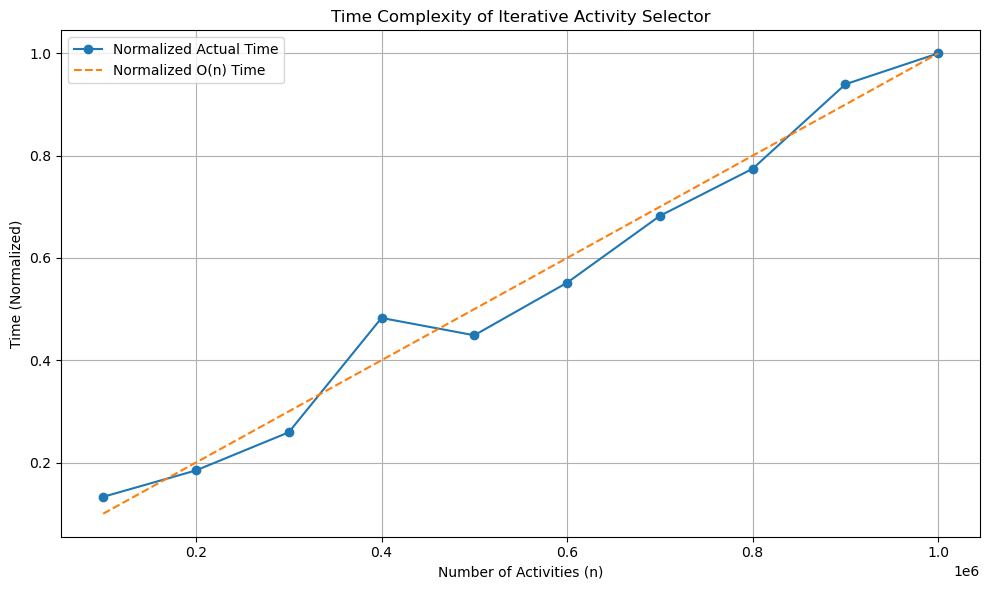

In [ ]:
# Iterative Activity Selector

import time
import random
import matplotlib.pyplot as plt

def iterative_activity_selector(s, f):
    n = len(s)
    A = [0]
    k = 0
    for m in range(1, n):
        if s[m] >= f[k]:
            A.append(m)
            k = m
    return A

# Measure actual time
def measure_iterative_activity_selector(sizes):
    actual_times = []
    theoretical = []

    for n in sizes:
        s = [0] + [random.randint(0, 1000) for _ in range(n-1)]
        f = [0] + [s[i] + random.randint(1, 100) for i in range(1, n)]

        start_time = time.time()
        iterative_activity_selector(s, f)
        end_time = time.time()

        actual_times.append(end_time - start_time)
        theoretical.append(n)

    return actual_times, theoretical

# Normalize for plotting
def normalize(data):
    max_val = max(data)
    return [d / max_val for d in data]

# Sizes to test
sizes = list(range(100000, 1000001, 100000))
actual, theory = measure_iterative_activity_selector(sizes)
norm_actual = normalize(actual)
norm_theory = normalize(theory)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(sizes, norm_actual, label="Normalized Actual Time", marker='o')
plt.plot(sizes, norm_theory, label="Normalized O(n) Time", linestyle='--')
plt.xlabel("Number of Activities (n)")
plt.ylabel("Time (Normalized)")
plt.title("Time Complexity of Iterative Activity Selector")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()